In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('./Dataset/customer.csv')

In [4]:
df.shape

(64374, 12)

In [5]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Churn'].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

In [9]:
df['Gender'].value_counts()

Gender
Female    34353
Male      30021
Name: count, dtype: int64

In [10]:
df.drop('CustomerID',axis=1,inplace=True)

In [11]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [12]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [13]:
df['Subscription Type'].unique()

array(['Basic', 'Standard', 'Premium'], dtype=object)

In [14]:
df['Contract Length'].unique()

array(['Monthly', 'Annual', 'Quarterly'], dtype=object)

In [15]:
df=pd.get_dummies(df, columns=['Gender', 'Subscription Type','Contract Length'], drop_first=True, dtype=int)

In [16]:
df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,1,0,0,0,1,0
1,41,28,28,7,13,584,20,0,0,0,1,1,0
2,47,27,10,2,29,757,21,0,1,1,0,0,0
3,35,9,12,5,17,232,18,0,1,1,0,0,1
4,53,58,24,9,2,533,18,0,0,0,1,0,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Age                         64374 non-null  int64
 1   Tenure                      64374 non-null  int64
 2   Usage Frequency             64374 non-null  int64
 3   Support Calls               64374 non-null  int64
 4   Payment Delay               64374 non-null  int64
 5   Total Spend                 64374 non-null  int64
 6   Last Interaction            64374 non-null  int64
 7   Churn                       64374 non-null  int64
 8   Gender_Male                 64374 non-null  int64
 9   Subscription Type_Premium   64374 non-null  int64
 10  Subscription Type_Standard  64374 non-null  int64
 11  Contract Length_Monthly     64374 non-null  int64
 12  Contract Length_Quarterly   64374 non-null  int64
dtypes: int64(13)
memory usage: 6.4 MB


In [18]:
x=df.drop('Churn',axis=1)

In [19]:
x.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,0,0,0,1,0
1,41,28,28,7,13,584,20,0,0,1,1,0
2,47,27,10,2,29,757,21,1,1,0,0,0
3,35,9,12,5,17,232,18,1,1,0,0,1
4,53,58,24,9,2,533,18,0,0,1,0,0


In [20]:
x.shape

(64374, 12)

In [21]:
y=df['Churn']

In [22]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: Churn, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2, random_state=1)

In [24]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [25]:
model=Sequential()

In [26]:
model.add(Dense(3,activation='sigmoid', input_dim=12))
model.add(Dense(1, activation='sigmoid'))

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43 (172.00 B)

 Trainable params: 43 (172.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(loss='binary_crossentropy', optimizer='Adam')

In [29]:
model.fit(xtrain,ytrain,epochs=20)

Epoch 1/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.7750
Epoch 2/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.7750
Epoch 2/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6918
Epoch 3/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6918
Epoch 3/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6918
Epoch 4/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6918
Epoch 4/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6918
Epoch 5/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6918
Epoch 5/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6918
Epoch 6/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6918
Epoch 6/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6918
Epoch 7/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6918
Epoch 7/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6918
Epoch 8/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6918
Epoch 8/20
1610/1610 ━━━━━━━━━━━━━

In [30]:
model.layers[0].get_weights()

[array([[ 0.08363372,  0.530683  , -0.01592559],
        [ 0.588648  ,  0.26627207,  0.62006634],
        [ 0.00734949,  0.02132612,  0.2861482 ],
        [ 0.4195115 ,  0.30249673, -0.37602606],
        [ 0.46942466, -0.07372111,  0.3968044 ],
        [ 0.35043246,  0.17542326,  0.47654754],
        [-0.34077096,  0.06405401,  0.15655684],
        [-0.21659037, -0.05200368,  0.06794953],
        [ 0.19042891, -0.5413404 , -0.14058584],
        [ 0.5844874 , -0.3859617 ,  0.04028589],
        [-0.4906418 , -0.5536258 ,  0.19483602],
        [-0.5751825 , -0.2424388 , -0.1733062 ]], dtype=float32),
 array([0., 0., 0.], dtype=float32)]

In [31]:
model.layers[1].get_weights()

[array([[-0.48389915],
        [-0.5230704 ],
        [ 0.32758543]], dtype=float32),
 array([0.5763041], dtype=float32)]

In [32]:
model.predict(xtest)

403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.47425276],
       [0.47425276],
       [0.47425276],
       ...,
       [0.47425276],
       [0.47425276],
       [0.47425276]], shape=(12875, 1), dtype=float32)

In [33]:
xtest_prob=model.predict(xtest)

403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [34]:
ypred=np.where(xtest_prob>0.5,1,0)

In [35]:
ypred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(12875, 1))

In [36]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.5245825242718447

# Modified

In [37]:
model1=Sequential()

In [38]:
model1.add(Dense(12,activation='relu', input_dim=12))
model1.add(Dense(12, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325 (1.27 KB)

 Trainable params: 325 (1.27 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model1.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [41]:
history=model1.fit(xtrain,ytrain, epochs=20, validation_split=0.2)

Epoch 1/20


1288/1288 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7147 - loss: 1.5604 - val_accuracy: 0.7509 - val_loss: 0.5031
Epoch 2/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7147 - loss: 1.5604 - val_accuracy: 0.7509 - val_loss: 0.5031
Epoch 2/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7750 - loss: 0.4729 - val_accuracy: 0.7865 - val_loss: 0.4510
Epoch 3/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7750 - loss: 0.4729 - val_accuracy: 0.7865 - val_loss: 0.4510
Epoch 3/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7973 - loss: 0.4335 - val_accuracy: 0.8186 - val_loss: 0.3980
Epoch 4/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7973 - loss: 0.4335 - val_accuracy: 0.8186 - val_loss: 0.3980
Epoch 4/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8072 - loss: 0.4213 - val_accuracy: 0.6900 - val_loss: 0.6861
Epoch 5/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8072 - loss: 0.4213 - val_accurac

In [42]:
history.history

{'accuracy': [0.7147018313407898,
  0.7750188112258911,
  0.7972766160964966,
  0.8072283267974854,
  0.8198742866516113,
  0.8380300402641296,
  0.8429087996482849,
  0.848418653011322,
  0.8490254878997803,
  0.8587586879730225,
  0.8625694513320923,
  0.8660889863967896,
  0.8689531087875366,
  0.8727153539657593,
  0.8758707642555237,
  0.8765018582344055,
  0.8769145011901855,
  0.8788563013076782,
  0.877569854259491,
  0.8784436583518982],
 'loss': [1.5603752136230469,
  0.4728536605834961,
  0.43350154161453247,
  0.4213271737098694,
  0.39162173867225647,
  0.35714271664619446,
  0.3433122932910919,
  0.3392585515975952,
  0.3345712423324585,
  0.3158235549926758,
  0.31016233563423157,
  0.2981216013431549,
  0.2968631982803345,
  0.288209468126297,
  0.2872503995895386,
  0.281992107629776,
  0.2812137007713318,
  0.2745203375816345,
  0.28021979331970215,
  0.2782876491546631],
 'val_accuracy': [0.7508738040924072,
  0.786504864692688,
  0.8186407685279846,
  0.689999997615

In [43]:
model1.layers[0].get_weights()

[array([[-1.53871298e-01,  4.57467288e-01,  8.85763690e-02,
         -3.09371471e-01, -5.81437349e-01, -2.01569319e-01,
          4.57925573e-02, -1.67705402e-01,  3.59629959e-01,
         -1.81469366e-01, -2.76782990e-01,  6.09877780e-02],
        [-1.45700812e-01, -1.33434430e-01, -5.82145810e-01,
         -4.51953173e-01, -1.27683699e-01, -3.13682228e-01,
          1.16901316e-01,  5.17591774e-01, -1.03808150e-01,
         -5.98006189e-01,  2.27514505e-02,  1.70056354e-02],
        [ 1.84486747e-01,  4.47925776e-02,  1.76737700e-02,
         -4.35724854e-01, -1.36906311e-01, -4.11545843e-01,
          4.08343971e-02,  1.17310941e-01, -1.69378781e+00,
          1.39513193e-03, -4.88421321e-01, -2.60286987e-01],
        [-3.27764034e-01, -3.34468693e-01, -7.33567238e-01,
         -1.57275081e-01, -7.86427975e-01,  7.44912922e-01,
          1.27939916e+00,  3.30389887e-01,  5.31218648e-01,
          2.49760103e+00, -2.20764875e-01, -1.00839496e+00],
        [ 1.15950584e-01,  2.8554096

In [44]:
model1.layers[1].get_weights()

[array([[ 2.49960184e-01,  1.43809319e-02, -4.78530288e-01,
          4.98290658e-01, -3.65676045e-01, -2.83098102e-01,
          4.59434867e-01,  1.33354664e-02,  2.75978327e-01,
          9.75399017e-02,  3.23877096e-01, -3.99228573e-01],
        [-2.03145027e-01, -1.22177005e-01,  2.12860063e-01,
         -3.21036518e-01,  2.33963817e-01, -3.59848320e-01,
          1.02328286e-01,  4.02057171e-01,  5.59373014e-02,
         -1.34915471e-01,  1.15637377e-01, -2.93501884e-01],
        [-1.24202557e-01, -5.06301880e-01, -4.27906960e-01,
          3.27653110e-01, -4.66893485e-04, -2.05457553e-01,
          4.18088615e-01,  2.55506039e-02,  1.55370861e-01,
         -5.98493040e-01,  4.75942194e-01, -3.92357826e-01],
        [ 1.12652779e-01, -2.82029986e-01, -3.50679159e-02,
          4.36917663e-01,  4.13026810e-01,  1.09401703e-01,
         -9.87017155e-03,  3.07985544e-01,  4.69352722e-01,
          3.58388901e-01, -1.50516510e-01, -4.73520517e-01],
        [-2.38926366e-01, -6.0440093

In [45]:
xtest_pro=model1.predict(xtest)

403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step


In [46]:
ypred=np.where(xtest_pro>0.5,1,0)

In [47]:
accuracy_score(ytest,ypred)

0.8836504854368932

In [48]:
import matplotlib.pyplot as plt

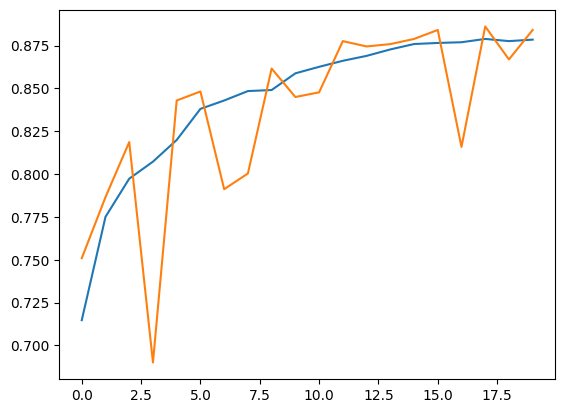

In [49]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

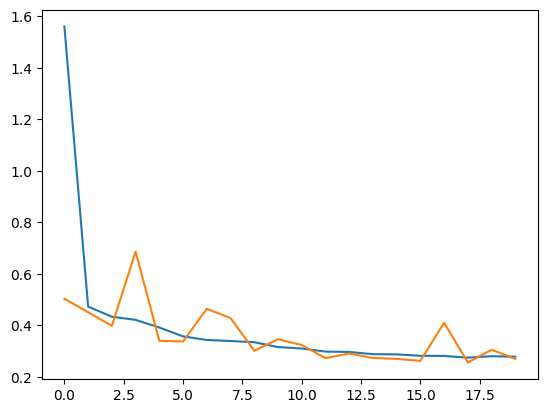

In [50]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Models I have Used are like below
  ReLU, Sigmoid, Tanh, Softmax, ELU Activations with Binary Crossentropy and Adam Optimizer.

In [61]:
# Model 2: ReLU activation, binary_crossentropy loss
model2 = Sequential()
model2.add(Dense(12, activation='relu', input_dim=12))
model2.add(Dense(12, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))
model2.summary()
model2.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
history2 = model2.fit(xtrain, ytrain, epochs=20, validation_split=0.2)

# Model 3: Tanh activation, mean_squared_error loss
model3 = Sequential()
model3.add(Dense(12, activation='tanh', input_dim=12))
model3.add(Dense(12, activation='tanh'))
model3.add(Dense(1, activation='sigmoid'))
model3.summary()
model3.compile(loss='mean_squared_error', optimizer='Adam', metrics=['accuracy'])
history3 = model3.fit(xtrain, ytrain, epochs=20, validation_split=0.2)

# Model 4: Softmax activation, categorical_crossentropy loss
from tensorflow.keras.utils import to_categorical
ytrain_cat = to_categorical(ytrain)
ytest_cat = to_categorical(ytest)
model4 = Sequential()
model4.add(Dense(12, activation='relu', input_dim=12))
model4.add(Dense(12, activation='relu'))
model4.add(Dense(2, activation='softmax'))
model4.summary()
model4.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
history4 = model4.fit(xtrain, ytrain_cat, epochs=20, validation_split=0.2)

# Model 5: ELU activation, hinge loss
model5 = Sequential()
model5.add(Dense(12, activation='elu', input_dim=12))
model5.add(Dense(12, activation='elu'))
model5.add(Dense(1, activation='sigmoid'))
model5.summary()
model5.compile(loss='hinge', optimizer='Adam', metrics=['accuracy'])
history5 = model5.fit(xtrain, ytrain, epochs=20, validation_split=0.2)


c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325 (1.27 KB)

 Trainable params: 325 (1.27 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325 (1.27 KB)

 Trainable params: 325 (1.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 2/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 2/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 3/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 3/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 4/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 4/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 5/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4742 - loss: 1.0515 - 